#  IMPORT LIBRARIES

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [72]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [73]:
df = pd.read_csv("Social_Media_Self_Diagnosis_Final_Clean_EN.csv")
df

,Timestamp,Age Group,Primary Social Media Platforms,Daily Time Spent,Search for Symptoms on Social Media Instead of Search Engines,Frequency of Medical Content Exposure (1-5),Commonly Self-Diagnosed Conditions Observed,Algorithmic Recommendations of Diagnostic Content,Action Taken When Seeing Matching Symptoms,General Feeling After Watching Self-Diagnosis Content,Verification of Content Creator Credibility,Suspected Self-Condition Based Solely on Video,Next Step After Suspecting Condition,Perceived Danger of Self-Diagnosis (1-5),Professional Consultation Post-Self-Diagnosis,Purchased Medication/Supplements Based on SM Advice,Content Simplifies Complex Issues (1-5)
0,3/15/2026 20:48,18-24,"TikTok, Instagram, YouTube, Facebook",More than 5 hours,Sometimes,4,"ADHD, Autism, Depression, Anxiety, Bipolar Dis...",Sometimes,"Save the video, Read comments",Anxiety and stress,If they mention scientific sources,Yes,Tried self-treatment,5.0,No,No,4
1,3/15/2026 20:51,18-24,"TikTok, Instagram, YouTube",3-5 hours,No,4,ADHD,"Yes, constantly",Skip it,Doubt and disbelief,If they are a specialized doctor,Yes,Did nothing,4.0,No,No,4
2,3/15/2026 20:57,18-24,"Instagram, Facebook",3-5 hours,No,1,Depression,Sometimes,"Watch the full video, Read comments",Doubt and disbelief,If they are a specialized doctor,No,Did nothing,3.0,No,No,5
3,3/15/2026 20:57,18-24,Facebook,1-3 hours,No,2,"Depression, Other",Sometimes,Read comments,Relief from understanding myself,If they mention scientific sources,No,Did nothing,3.0,No,No,4
4,3/15/2026 20:58,18-24,"TikTok, Instagram",3-5 hours,Always,3,"ADHD, Autism, Depression, Anxiety, Bipolar Dis...",Sometimes,Watch the full video,Doubt and disbelief,If they are a specialized doctor,Yes,Did nothing,5.0,No,No,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,3/20/2026 10:34,45 or older,"Facebook, TikTok",3-5 hours,Sometimes,4,"Bipolar Disorder, Autism",Sometimes,Save the video,Relief from understanding myself,I don't verify the information,NaN,Did nothing,NaN,No,No,3
351,3/18/2026 5:13,18-24,"YouTube, X (Twitter), Facebook",3-5 hours,Sometimes,1,Digestive Issues,Sometimes,Read comments,Doubt and disbelief,I don't verify the information,NaN,Did nothing,NaN,No,No,4
352,3/22/2026 18:46,25-34,"X (Twitter), TikTok",More than 5 hours,Sometimes,3,"Digestive Issues, Bipolar Disorder, Other, ADHD",No,"Save the video, Watch the full video",Anxiety and stress,Based on follower count,NaN,Tried self-treatment,NaN,Yes,No,3
353,3/19/2026 3:33,45 or older,"Instagram, Reddit",3-5 hours,Sometimes,3,"Digestive Issues, Depression","Yes, constantly",Read comments,Confusion,If they are a specialized doctor,NaN,Consulted a specialist,NaN,No,No,4


# Data Cleaning

In [74]:
# Fix NaNs (Suspected + Danger → No suspicion)
df['Suspected Self-Condition Based Solely on Video'] = df['Suspected Self-Condition Based Solely on Video'].fillna('No')
df['Perceived Danger of Self-Diagnosis (1-5)'] = df['Perceived Danger of Self-Diagnosis (1-5)'].fillna(0)

In [75]:
# Fill any remaining
df = df.fillna('Unknown')

In [76]:
# Numeric columns
numeric_cols = ['Frequency of Medical Content Exposure (1-5)', 
                'Perceived Danger of Self-Diagnosis (1-5)', 
                'Content Simplifies Complex Issues (1-5)']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.shape)

(355, 17)


# BASIC INFO

In [77]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 17 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Timestamp                                                      355 non-null    object 
 1   Age Group                                                      355 non-null    object 
 2   Primary Social Media Platforms                                 355 non-null    object 
 3   Daily Time Spent                                               355 non-null    object 
 4   Search for Symptoms on Social Media Instead of Search Engines  355 non-null    object 
 5   Frequency of Medical Content Exposure (1-5)                    355 non-null    int64  
 6   Commonly Self-Diagnosed Conditions Observed                    355 non-null    object 
 7   Algorithmic Recommendations of Diagnostic Content             

In [78]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Timestamp                                                        0
Age Group                                                        0
Primary Social Media Platforms                                   0
Daily Time Spent                                                 0
Search for Symptoms on Social Media Instead of Search Engines    0
Frequency of Medical Content Exposure (1-5)                      0
Commonly Self-Diagnosed Conditions Observed                      0
Algorithmic Recommendations of Diagnostic Content                0
Action Taken When Seeing Matching Symptoms                       0
General Feeling After Watching Self-Diagnosis Content            0
Verification of Content Creator Credibility                      0
Suspected Self-Condition Based Solely on Video                   0
Next Step After Suspecting Condition                             0
Perceived Danger of Self-Diagnosis (1-5)                         0
Professional Consultation Post-Self-Diagnosi

In [79]:
print(df[numeric_cols].describe().round(2))

       Frequency of Medical Content Exposure (1-5)  \
count                                       355.00   
mean                                          2.52   
std                                           1.27   
min                                           1.00   
25%                                           1.00   
50%                                           2.00   
75%                                           3.00   
max                                           5.00   

       Perceived Danger of Self-Diagnosis (1-5)  \
count                                    355.00   
mean                                       2.05   
std                                        1.95   
min                                        0.00   
25%                                        0.00   
50%                                        2.00   
75%                                        4.00   
max                                        5.00   

       Content Simplifies Complex Issues (1-5)  
coun

# Key Business Insights

In [80]:
print(f"Total respondents: {len(df)}")

Total respondents: 355


In [81]:
print(f"18-24 age group: {df['Age Group'].value_counts(normalize=True)['18-24']*100:.1f}%")

18-24 age group: 83.1%


In [82]:
print(f"Most common platforms: {df['Primary Social Media Platforms'].str.split(', ').explode().value_counts().head(6).to_dict()}")

Most common platforms: {'Instagram': 167, 'Facebook': 152, 'TikTok': 135, 'YouTube': 124, 'X (Twitter)': 63, 'Reddit': 61}


In [83]:
print(f"Most self-diagnosed conditions: {df['Commonly Self-Diagnosed Conditions Observed'].str.split(', ').explode().value_counts().head(7).to_dict()}")

Most self-diagnosed conditions: {'Depression': 187, 'ADHD': 128, 'Anxiety': 122, 'Other': 111, 'Autism': 87, 'Digestive Issues': 84, 'Bipolar Disorder': 77}


In [84]:
print(f"Ever suspected condition from video: { (df['Suspected Self-Condition Based Solely on Video'] == 'Yes').mean()*100 :.1f}%")

Ever suspected condition from video: 32.7%


In [85]:
print(f"Consulted a doctor after self-diagnosis: { (df['Professional Consultation Post-Self-Diagnosis'] == 'Yes').mean()*100 :.1f}%")

Consulted a doctor after self-diagnosis: 9.6%


In [86]:
print(f"Bought medication/supplements based on SM: { (df['Purchased Medication/Supplements Based on SM Advice'] == 'Yes').mean()*100 :.1f}%")

Bought medication/supplements based on SM: 3.4%


In [87]:
print(f"Avg perceived danger: {df['Perceived Danger of Self-Diagnosis (1-5)'].mean():.2f}/5")

Avg perceived danger: 2.05/5


In [88]:
print(f"Avg 'content simplifies complex issues': {df['Content Simplifies Complex Issues (1-5)'].mean():.2f}/5")

Avg 'content simplifies complex issues': 3.95/5


# Univariate Analysis + Visualizations

<Axes: xlabel='Age Group', ylabel='count'>

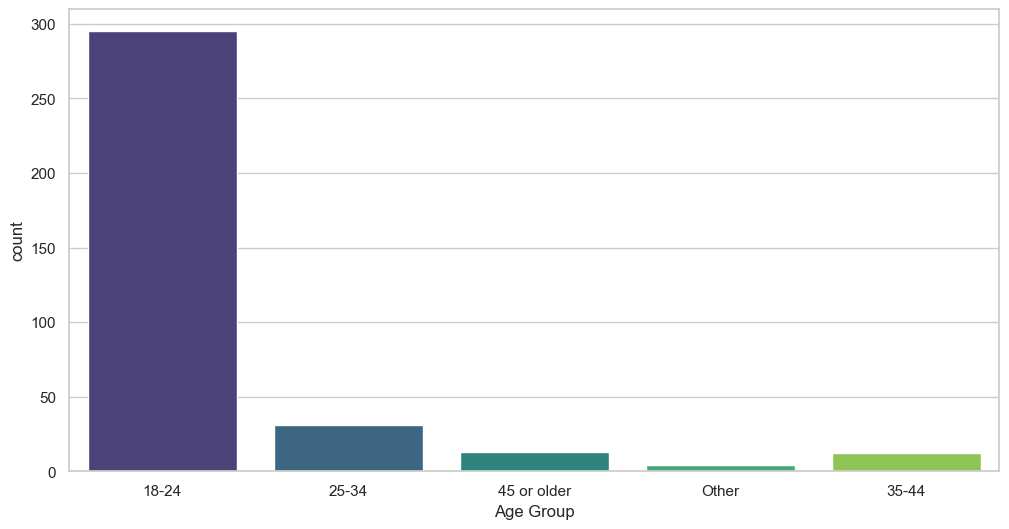

In [89]:
# Age Group
sns.countplot(data=df, x='Age Group', hue='Age Group', palette='viridis', legend=False)

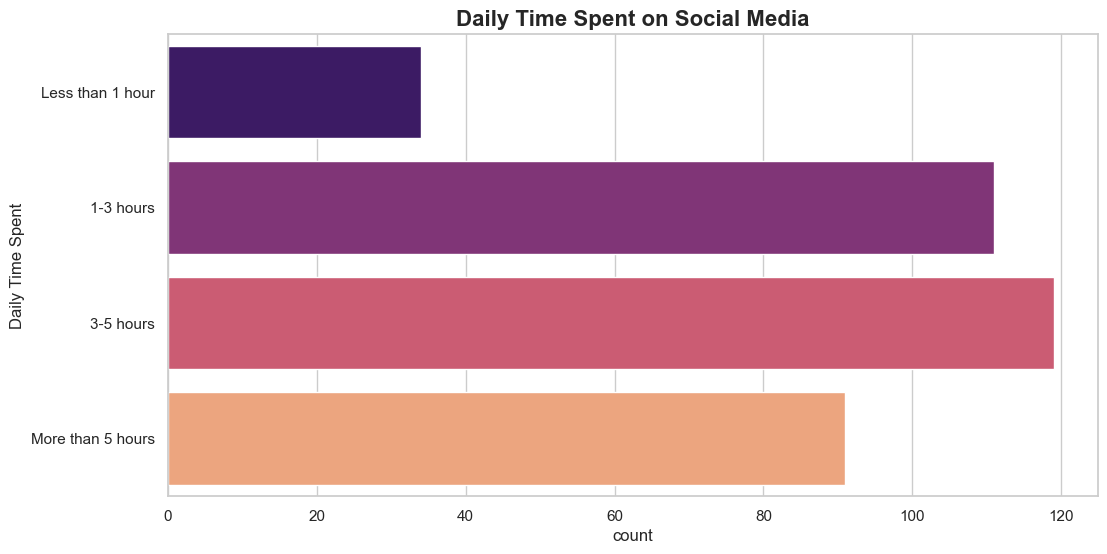

In [90]:
#  Daily Time Spent
sns.countplot(data=df, y='Daily Time Spent', order=['Less than 1 hour', '1-3 hours', '3-5 hours', 'More than 5 hours'], palette='magma')
plt.title('Daily Time Spent on Social Media', fontsize=16, fontweight='bold')
plt.show()

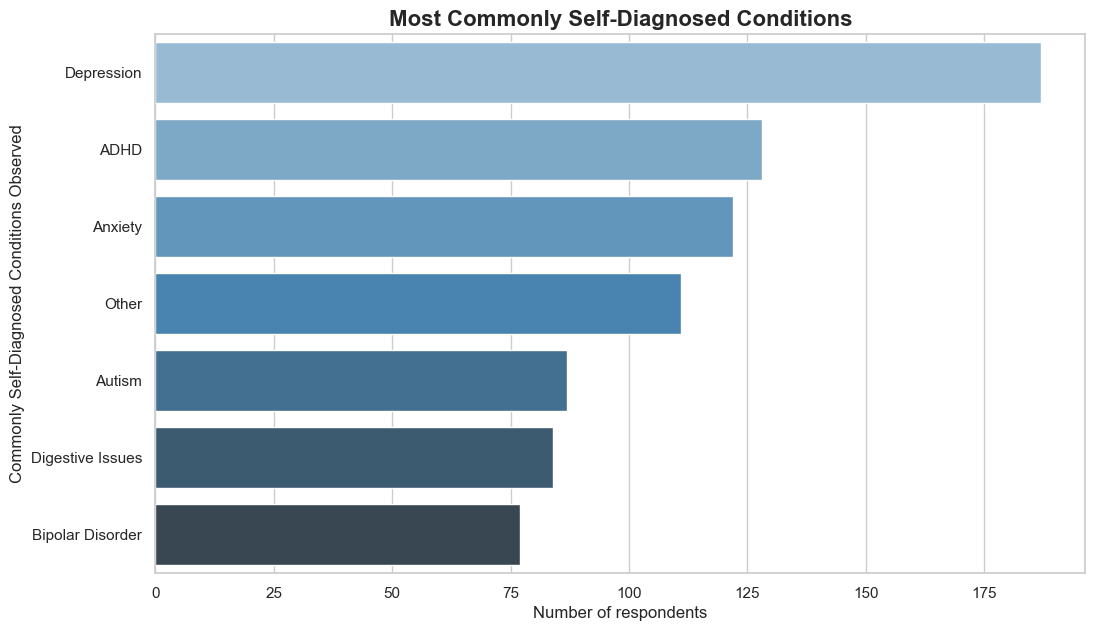

In [91]:
#  Top Self-Diagnosed Conditions
conditions = df['Commonly Self-Diagnosed Conditions Observed'].str.split(', ').explode().value_counts().head(10)
plt.figure(figsize=(12,7))
sns.barplot(x=conditions.values, y=conditions.index, palette='Blues_d')
plt.title('Most Commonly Self-Diagnosed Conditions', fontsize=16, fontweight='bold')
plt.xlabel('Number of respondents')
plt.show()


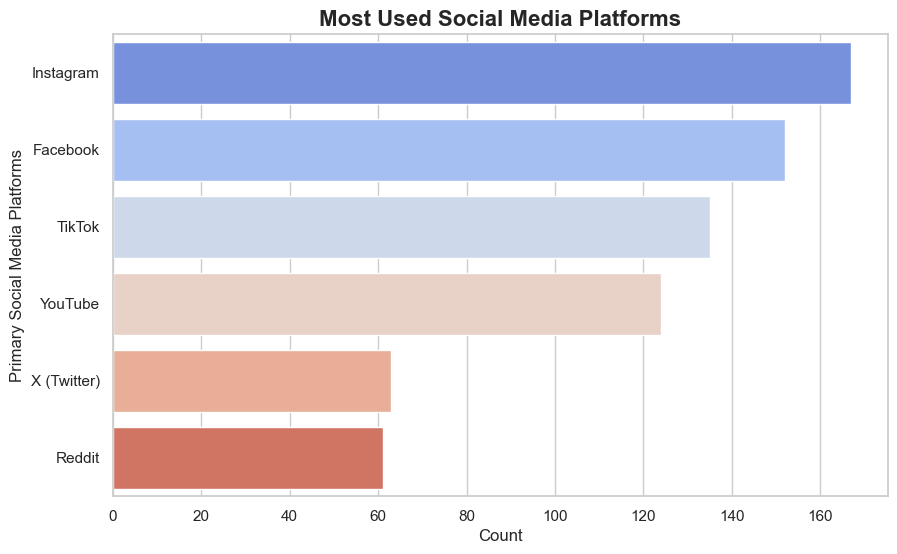

In [92]:
#  Top Platforms (exploded)
platforms = df['Primary Social Media Platforms'].str.split(', ').explode().value_counts().head(8)
plt.figure(figsize=(10,6))
sns.barplot(x=platforms.values, y=platforms.index, palette='coolwarm')
plt.title('Most Used Social Media Platforms', fontsize=16, fontweight='bold')
plt.xlabel('Count')
plt.show()


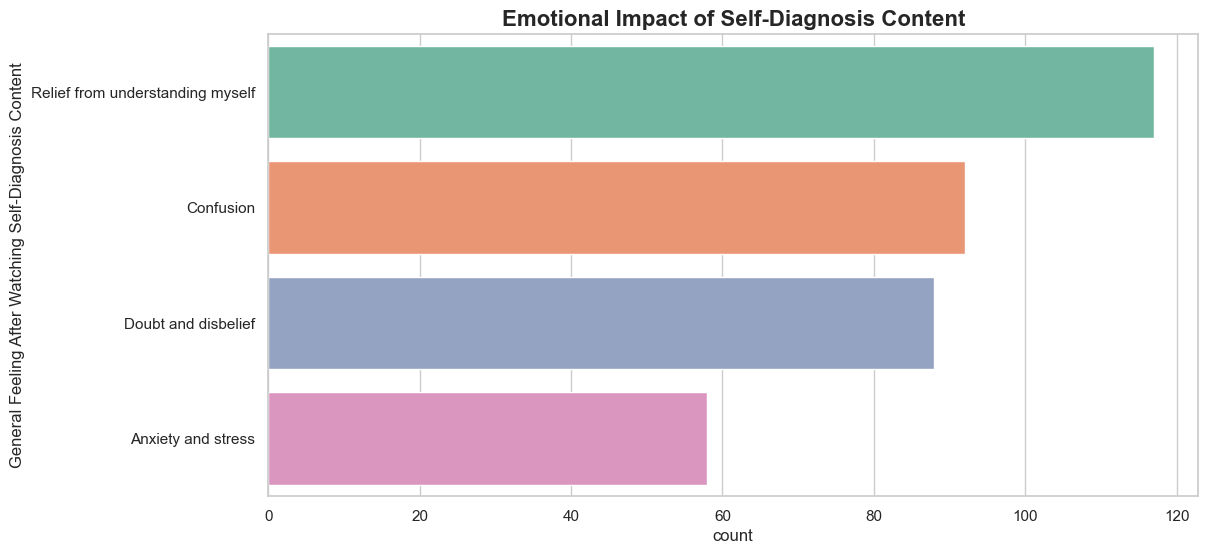

In [93]:
#  Feelings after watching
sns.countplot(data=df, y='General Feeling After Watching Self-Diagnosis Content', 
              order=df['General Feeling After Watching Self-Diagnosis Content'].value_counts().index, palette='Set2')
plt.title('Emotional Impact of Self-Diagnosis Content', fontsize=16, fontweight='bold')
plt.show()


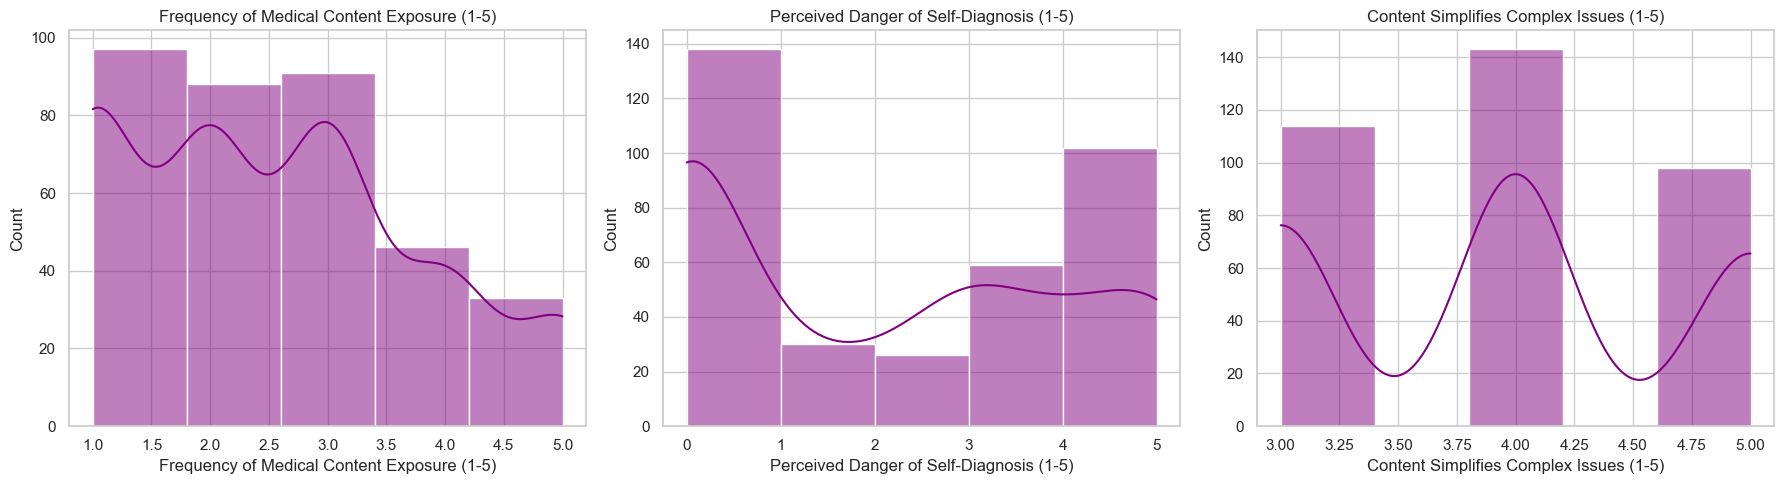

In [94]:
#  Likert Scales Distribution
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=5, kde=True, ax=axes[i], color='purple')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [95]:
# Cross-tab: Time spent vs. Suspected condition
pd.crosstab(df['Daily Time Spent'], df['Suspected Self-Condition Based Solely on Video'], normalize='index')*100


Suspected Self-Condition Based Solely on Video,No,Yes
Daily Time Spent,,
1-3 hours,64.864865,35.135135
3-5 hours,66.386555,33.613445
Less than 1 hour,82.352941,17.647059
More than 5 hours,65.934066,34.065934


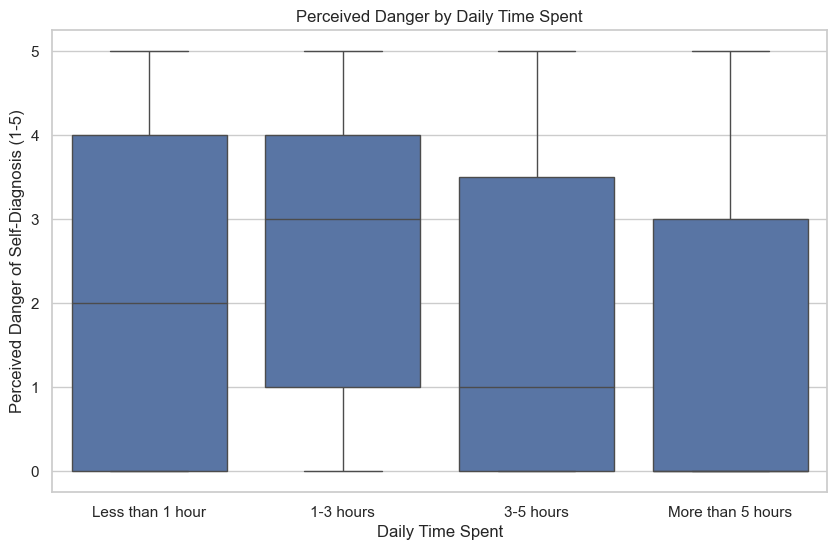

In [96]:
# Time spent vs. Perceived Danger
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Daily Time Spent', y='Perceived Danger of Self-Diagnosis (1-5)', 
            order=['Less than 1 hour', '1-3 hours', '3-5 hours', 'More than 5 hours'])
plt.title('Perceived Danger by Daily Time Spent')
plt.show()


Consultation Rate by Platform (%):
Professional Consultation Post-Self-Diagnosis     No    Yes
Platform                                                   
Facebook                                       94.08   5.92
Instagram                                      94.01   5.99
Reddit                                         81.97  18.03
TikTok                                         89.63  10.37
X (Twitter)                                    76.19  23.81
YouTube                                        94.35   5.65


<Figure size 1200x700 with 0 Axes>

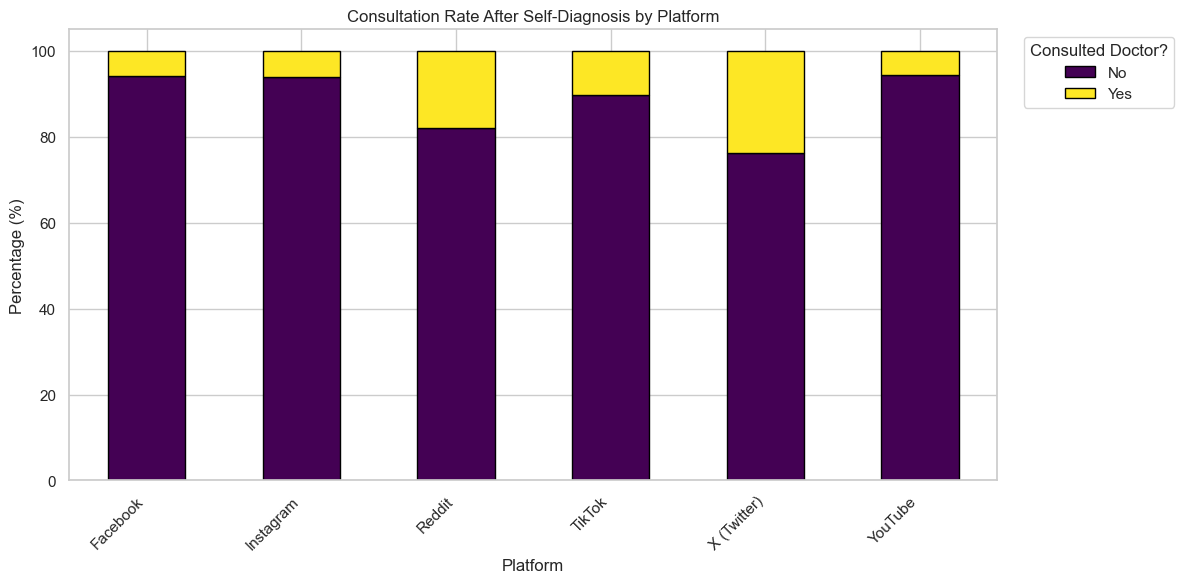

In [97]:
# Explode platforms for accurate per-platform analysis
df_exploded = df.assign(
    Platform=df['Primary Social Media Platforms'].str.split(', ')
).explode('Platform')

# Platform vs. Consultation Rate
platform_consult = (
    df_exploded
    .groupby('Platform')['Professional Consultation Post-Self-Diagnosis']
    .value_counts(normalize=True)
    .unstack(fill_value=0) 
    * 100
)

print("Consultation Rate by Platform (%):")
print(platform_consult.round(2))

# Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 7))
platform_consult.plot(
    kind='bar', 
    stacked=True, 
    colormap='viridis', 
    edgecolor='black'
)
plt.title('Consultation Rate After Self-Diagnosis by Platform')
plt.ylabel('Percentage (%)')
plt.xlabel('Platform')
plt.legend(title='Consulted Doctor?', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

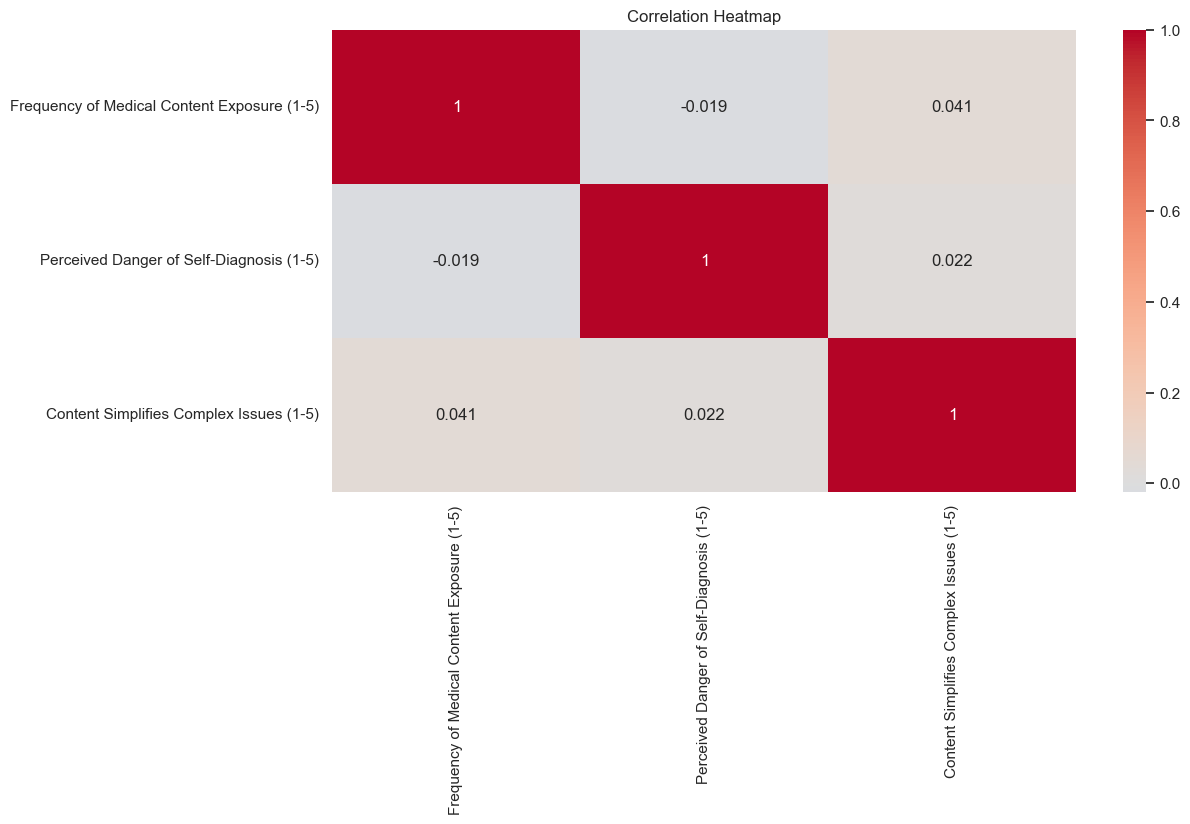

In [98]:
# Correlation heatmap
corr = df[numeric_cols + ['Suspected Self-Condition Based Solely on Video']].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

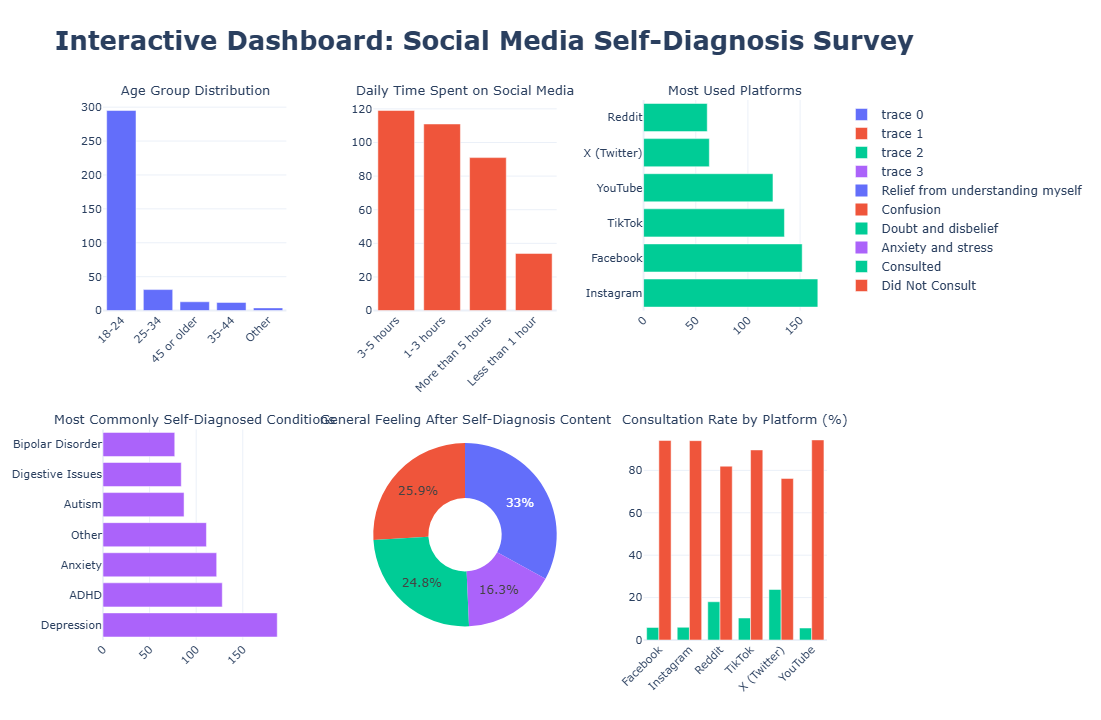

In [99]:
#Exploded DataFrame 
df_exploded = df.assign(
    Platform=df['Primary Social Media Platforms'].str.split(', ')
).explode('Platform')

# Interactive Dashboard 
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        "Age Group Distribution",
        "Daily Time Spent on Social Media",
        "Most Used Platforms",
        "Most Commonly Self-Diagnosed Conditions",
        "General Feeling After Self-Diagnosis Content",
        "Consultation Rate by Platform (%)"
    ),
    specs=[[{"type": "bar"}, {"type": "bar"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "pie"}, {"type": "bar"}]],
    vertical_spacing=0.22,      
    horizontal_spacing=0.12    
)

# 1. Age Group
age_count = df['Age Group'].value_counts()
fig.add_trace(go.Bar(x=age_count.index, y=age_count.values, marker_color='#636EFA'), row=1, col=1)

# 2. Daily Time Spent
time_count = df['Daily Time Spent'].value_counts()
fig.add_trace(go.Bar(x=time_count.index, y=time_count.values, marker_color='#EF553B'), row=1, col=2)

# 3. Most Used Platforms
platforms = df_exploded['Platform'].value_counts().head(8)
fig.add_trace(go.Bar(y=platforms.index, x=platforms.values, orientation='h', marker_color='#00CC96'), row=1, col=3)

# 4. Most Commonly Self-Diagnosed Conditions
conditions = df['Commonly Self-Diagnosed Conditions Observed'].str.split(', ').explode().value_counts().head(10)
fig.add_trace(go.Bar(y=conditions.index, x=conditions.values, orientation='h', marker_color='#AB63FA'), row=2, col=1)

# 5. General Feeling (Pie)
feeling_count = df['General Feeling After Watching Self-Diagnosis Content'].value_counts()
fig.add_trace(go.Pie(labels=feeling_count.index, values=feeling_count.values, hole=0.4), row=2, col=2)

# 6. Consultation Rate by Platform
consult_rate = (
    df_exploded
    .groupby('Platform')['Professional Consultation Post-Self-Diagnosis']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

fig.add_trace(go.Bar(x=consult_rate.index, y=consult_rate['Yes'], name='Consulted', marker_color='#00CC96'), row=2, col=3)
fig.add_trace(go.Bar(x=consult_rate.index, y=consult_rate['No'], name='Did Not Consult', marker_color='#EF553B'), row=2, col=3)

# ====================== Final Layout ======================
fig.update_layout(
    height=720,      
    width=1450,      
    title_text="<b>Interactive Dashboard: Social Media Self-Diagnosis Survey</b>",
    title_font_size=26,
    showlegend=True,
    template="plotly_white",
    barmode='group'
)


fig.update_annotations(font_size=13)                   
fig.update_xaxes(tickangle=-45, tickfont=dict(size=11)) 
fig.update_yaxes(tickfont=dict(size=11))

fig.show()